In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("Apple.csv")
df.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,OpenInt,Stock
0,0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0,AAPL
1,1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0,AAPL
2,2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0,AAPL
3,3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0,AAPL
4,4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0,AAPL


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8364 non-null   int64  
 1   Date        8364 non-null   str    
 2   Open        8364 non-null   float64
 3   High        8364 non-null   float64
 4   Low         8364 non-null   float64
 5   Close       8364 non-null   float64
 6   Volume      8364 non-null   int64  
 7   OpenInt     8364 non-null   int64  
 8   Stock       8364 non-null   str    
dtypes: float64(4), int64(3), str(2)
memory usage: 588.2 KB


In [5]:
df.isnull().sum()

Unnamed: 0    0
Date          0
Open          0
High          0
Low           0
Close         0
Volume        0
OpenInt       0
Stock         0
dtype: int64

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

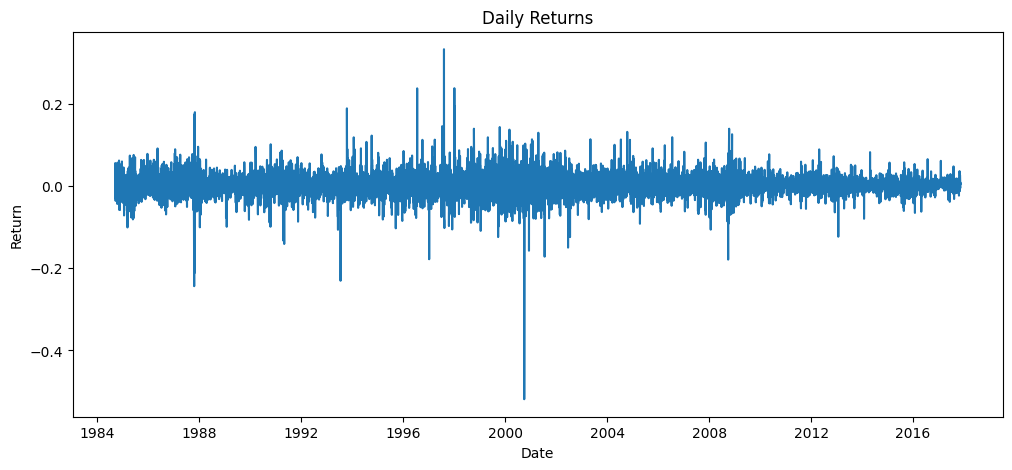

In [11]:
df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Daily_Return'])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

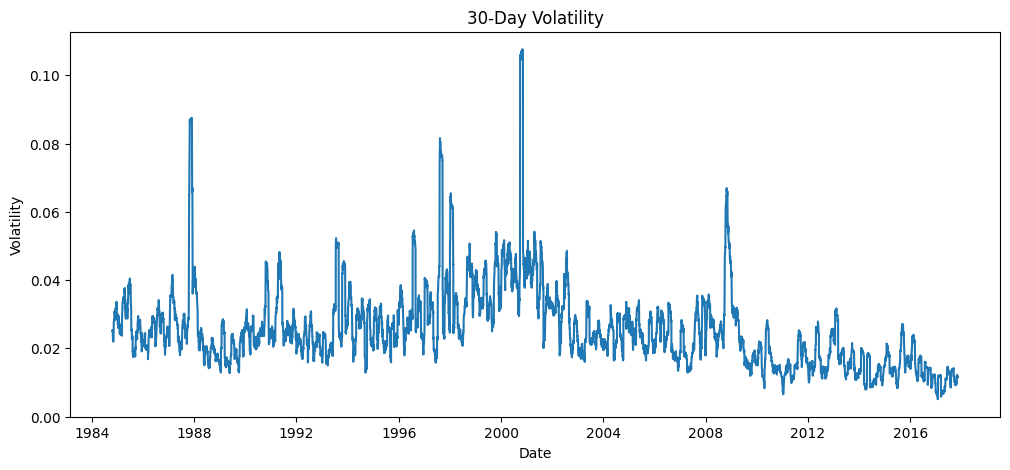

In [12]:
df['Volatility'] = df['Daily_Return'].rolling(30).std()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Volatility'])
plt.title("30-Day Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

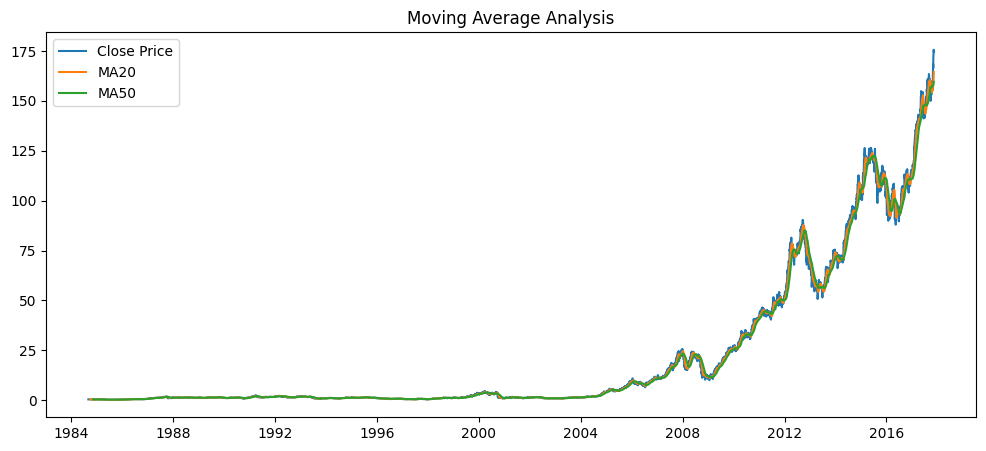

In [13]:
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')
plt.title("Moving Average Analysis")
plt.legend()
plt.show()

In [14]:
df = df.dropna()
features = ["Open","High","Low","Volume","MA20","MA50"]
X = df[features]
y = df["Close"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.14096704804569885
RMSE: 0.32757758216835936
R2 Score: 0.9999308489883902


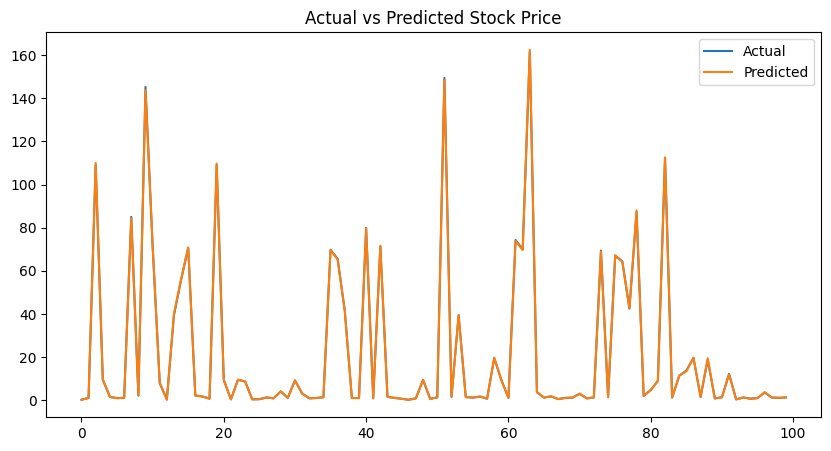

In [20]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")
plt.title("Actual vs Predicted Stock Price")
plt.legend()
plt.show()

In [21]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.14096704804569885
RMSE: 0.32757758216835936
R2 Score: 0.9999308489883902
